In [58]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Lad 𝑀 være matricen


Hvilken af følgende er en egenværdi for 𝑀?

Det karakteristiske polynomium sættes op som vist i afsnit 21.5 af notesættet.
\begin{align*}
\text{det}(A - \lambda I_{3}) & = \text{det}\left( \begin{bmatrix}
\frac{1}{3} - \lambda & \frac{1}{5} & \frac{3}{6} \\
\frac{1}{3} & \frac{2}{5} - \lambda & \frac{2}{6} \\
\frac{1}{3} & \frac{2}{5} & \frac{1}{6} - \lambda
\end{bmatrix} \right)\\
 & =
\left( \frac{1}{3} - \lambda \right) \cdot \left( \left(\frac{2}{5} - \lambda\right)\cdot \left( \frac{1}{6} - \lambda \right) - \frac{2}{6} \cdot \frac{2}{5} \right) - \frac{1}{5} \cdot \left( \frac{1}{3} \cdot \left( \frac{1}{6} - \lambda \right) - \left( \frac{2}{6} \cdot \frac{1}{3}\right) \right) + \frac{3}{6} \cdot \left( \frac{1}{3} \cdot \frac{2}{5} - \left( \frac{2}{5} - \lambda \right) \cdot \frac{1}{3 }\right)
\end{align*}
Ud fra dette kan det karakteristiske polynomium findes ved at reducere udtrykket. Reduceringen gøres med Sympy som CAS-værktøj.

In [59]:
lam = sp.symbols("lambda")

polynomium = (1/3 - lam) * ((2/5 - lam) * (1/6 - lam) - 2/6 * 2/5) - 1/5 * (1/3 * (1/6 - lam) - 2/6 * 1/3) + 3/6 * (1/3 * 2/5 - (2/5 - lam) * 1/3)
sp.solve((polynomium , 0), lam)

[(-0.166666666666667,), (0.0666666666666667,), (1.00000000000000,)]

Svaret er B.

## Opgave 2. (10 point) Betragt den følgende basis for ℝ2 givet ved:


Bestem koordinatvektoren til 𝑏 =(−1,−1) mht. ovenstående basis.

Definition 19.6 fra notesættet siger at koordinatvektoren med hensyn til basen kan findes ved at løse det lineær ligningssystem:
$$
A x = b, \qquad A = (v_{0}, v_{1})
$$
Denne ligning vil løses ved at reducere til echelon form og derefter lave back substitution. Echelon form findes gennem en selvlavet funktion, hvorefter back substitution laves med en funktion fra notesættet.

In [60]:
# Selvlavet funktion, som får matricer ned på reduceret echelonform
def reduce_echelon(A, last_col = True):
    # finder dimensioner
    rows, cols = A.shape

    # hvis b er en del af matricen og man ikke vil reducere sidste søjle
    if not last_col:
        cols -= 1

    # holder styr på søjlen til senere
    cur_col = 0

    # reducerer for hver række
    for i in range(rows):

        # hvis der er flere rækker end søjler skipper man de sidste (nulrækker)
        if cur_col >= cols:
            return A
        
        # hvis nuværende søjle har 0 som element skal rækken byttes
        while A[i, cur_col] == 0:

            # finder en række uden 0 til at bytte med
            for j in range(i+1, rows):
                if A[j, cur_col] != 0:
                    A[[i,j], :] = A[[j,i], :]
                    break

            # hvis ingen passer er der ingen pivotelement i søjlen så næste søjle vælges
            # (while løkken kan fortsætte efter der plusses)
            cur_col += 1

            # hvis cur_col overstiger cols i while løkken skal den stadig stoppe
            if cur_col >= cols:
                return A

        # hvis første element i søjlen ikke er 0 kan rækkeoperationer endelig laves
        if A[i, cur_col] != 0:
            A[i] /= A[i, cur_col]   # deler rækken med pivotelementet så den bliver 1
            for j in range(i+1, rows):
                A[j] -= A[j,cur_col] * A[i] # trække række fra andre rækker så de bliver 0 i søjlen
        
        # søjlen bliver ikke incremented automatisk
        cur_col += 1
    return A

In [61]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [62]:
v0 = np.array([3, 2], dtype=float)[:, np.newaxis]
v1 = np.array([-3, 3], dtype=float)[:, np.newaxis]
b = np.array([-1, -1], dtype=float)[:, np.newaxis]

A = np.column_stack((v0, v1, b))
lign = reduce_echelon(A, last_col=False)
back_subs(lign[:, :2], lign[:, 2])

array([[-0.4       ],
       [-0.06666667]])

Svaret er C.

### Opgave 3. (10 point) Betragt en matrix 𝐴 ∈ ℝ5×3. Hvis dimensionen af nulrummet opfylder dim 𝑁(𝐴) =1, hvad er dimensionen af søjlerummet 𝑆(𝐴)?

Et nulrum med $\text{dim } N(A) = 1$  svarer til at der er en fri variabel i A på reduceret echelonform. Med 3 søjler i alt vil det betyde, at der er 2 pivotsøjler jvf. proposition 19.12 og dermed et søjlerum med $\text{dim } S(A) = 2$. Svaret er da A.

## Opgave 4. (10 point) Lad 𝑢 og 𝑣 være vektorer i ℝ100, som er ikke nul. Sæt 𝑠 =2/∥𝑢∥22 og 𝑡 =2/∥𝑣∥22. Lad 𝐻1 =𝐼100 −𝑠𝑢𝑢𝑇 og 𝐻2 =𝐼100 −𝑡𝑣𝑣𝑇 være de resulterende Householder matricer. Hvis 𝑢,𝑣 er ortogonal, forklar hvorfor

𝐻1𝐻2 =𝐼100 −𝑠𝑢𝑢𝑇 −𝑡𝑣𝑣𝑇 .

Angiv antallet flops der skal bruges for at beregne den højre side i formen
𝐼100 −(𝑠𝑢)𝑢𝑇 −(𝑡𝑣)𝑣𝑇 når 𝑠,𝑡,𝑢,𝑣 er kendt.

Jvf. den distributive lov fra proposition 4.13 kan følgende omskrivning laves:
\begin{align*}
H_{1}H_{2} & = (I_{100} - suu^{T}) (I_{100} - tvv^{T}) \\
 & = I_{100} (I_{100} - tvv^{T}) - suu^{T} (I_{100} - tvv^{T}) \\
 & = I_{100} I_{100} - I_{100} tvv^{T} - suu^{T} I_{100} + suu^{T} tvv^{T} \\
 & = I_{100} - tvv^{T} - suu^{T} + su(u^{T}tv)v^{T} \\
 & = I_{100} - tvv^{T} - suu^{T} + su(0)v^{T} \\
 & = I_{100} - tvv^{T} - suu^{T}
\end{align*}
Sidste skridt kan laves da $u$ og $v$ er ortogonale, hvilket betyder at $u$ og $tv$ også må være ortogonale. Deres indre produkt må da være 0.

Beregningen består af:
* to skalarprodukter af $100$ flops ($su$ og $tv$)
* to ydre_produkter af $100 \cdot 100$ flops ($(su) u^{T}$ og $(tv) v^{T}$)
* to matrixsum af $100 \cdot 100$ flops ($I_{100} + (suu^{T})$ og $I_{100} + (tvv^{T})$)

In [63]:
skalar_produkt = 100
ydre_produkt = 100*100
matrixsum = 100*100

print("Antallet af flops bliver da", 2*matrixsum + 2*ydre_produkt + 2*skalar_produkt)

Antallet af flops bliver da 40200


## Opgave 5. (20 point) Betragt den følgende afbildning 𝐿: ℝ4 →ℝ3:
𝐿(𝑥,𝑦,𝑧,𝑤) =(𝑥 +𝑦 −2𝑤,𝑥 −𝑦 +2𝑧,𝑦 −𝑧 −𝑤).

### (a) Gør rede for at 𝐿 er en lineær transformation, og at dens standardmatrix matrixrepræsentation er

For at $L$ kan være en lineær afbildning skal den følge egenskab (b) af proposition 18.12. Dette kan tjekkes ved at opskrive relationen således:
$$
\begin{align*}
L(su + tv) & =
su + tv
\left(
\begin{bmatrix}
1 \\
1 \\
0 \\
-2
\end{bmatrix}
+
\begin{bmatrix}
1 \\
-1 \\
2 \\
0
\end{bmatrix}
+
\begin{bmatrix}
0 \\
1 \\
-1 \\
-1
\end{bmatrix}
\right) \\
 & =
\begin{bmatrix}
su_{0} \\
su_{1} \\
0 \\
-2su_{3}
\end{bmatrix}
+
\begin{bmatrix}
su_{0} \\
-su_{1} \\
2su_{2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
0 \\
su_{1} \\
-su_{2} \\
-su_{3}
\end{bmatrix}
+
\begin{bmatrix}
tv_{0} \\
tv_{1} \\
0 \\
-2tv_{3}
\end{bmatrix}
+
\begin{bmatrix}
tv_{0} \\
-tv_{1} \\
2tv_{2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
0 \\
tv_{1} \\
-tv_{2} \\
-tv_{3}
\end{bmatrix} \\
 & =
s \cdot \left(
\begin{bmatrix}
u_{0} \\
u_{1} \\
0 \\
-2u_{3}
\end{bmatrix}
+
\begin{bmatrix}
u_{0} \\
-u_{1} \\
2u_{2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
0 \\
u_{1} \\
-u_{2} \\
-u_{3}
\end{bmatrix}\right)
+
t \cdot \left(
\begin{bmatrix}
v_{0} \\
v_{1} \\
0 \\
-2v_{3}
\end{bmatrix}
+
\begin{bmatrix}
v_{0} \\
-v_{1} \\
2v_{2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
0 \\
v_{1} \\
-v_{2} \\
-v_{3}
\end{bmatrix}\right) \\
 & = s \cdot L(u) + t \cdot L(v)
\end{align*}
$$

Da $L(su + tv) = s \cdot L(u) + t \cdot L(v)$ er $L$ en lineær transformation.

Ud fra proposition 18.14 vides det at for alle søjler i A skal det gælde at:
$$
u_{j} = L(e_{j})
$$
Dette tjekkes i numpy således:

In [64]:
A = np.array([[1, 1, 0, -2],
              [1, -1, 2, 0],
              [0, 1, -1, -1]], dtype=float)

def L(x, y , z, w):
    result = np.zeros((3,1))
    result[0] = x + y - 2*w
    result[1] = x - y + 2*z
    result[2] = y - z - w
    return result

for i in range(4):
    # definerer basisvektor
    e = np.zeros((4,1))
    e[i] = 1

    # når A[:, i] kaldes blive det til en liste, så [:, np.newaxis] gør det til en vektor igen
    print(np.all(A[:,i][:, np.newaxis] == L(e[0], e[1], e[2], e[3])))

True
True
True
True


### (b) Ved at reducere 𝐴 til echelonform, bestem en basis for nulrummet 𝑁(𝐴) og vis at

udgør en basis for søjlerummet 𝑆(𝐴).

In [65]:
A = np.array([[1, 1, 0, -2],
              [1, -1, 2, 0],
              [0, 1, -1, -1]], dtype=float)

echelon = reduce_echelon(A)
echelon

array([[ 1.,  1.,  0., -2.],
       [-0.,  1., -1., -1.],
       [ 0.,  0.,  0.,  0.]])

Ud fra echelonformen kan det ses at pivotsøjlerne er 0 og 1. Basisen for søjlerummet er da:
$$
v_{0} =
\begin{bmatrix}
1 \\
1 \\
0
\end{bmatrix}
, \qquad
v_{1} =
\begin{bmatrix}
1 \\
-1 \\
1
\end{bmatrix}
$$

In [66]:
echelon[0] -= echelon[1]
echelon

array([[ 1.,  0.,  1., -1.],
       [-0.,  1., -1., -1.],
       [ 0.,  0.,  0.,  0.]])

Følgende ligninger opstilles:
$$
\begin{align*}
x_{0} + x_{2} - x_{3} = 0 & \Leftrightarrow x_{0} = x_{3} - x_{2} \\
x_{1} - x_{2} - x_{3} = 0 & \Leftrightarrow x_{1} = x_{2} + x_{3} \\
\end{align*}
$$

Den generelle løsning bliver:
$$
\begin{bmatrix}
x_{0} \\
x_{1} \\
x_{2} \\
x_{3}
\end{bmatrix}
=
\begin{bmatrix}
x_{3} - x_{2} \\
x_{2} + x_{3} \\
x_{2} \\
x_{3}
\end{bmatrix}
=
x_{2}
\begin{bmatrix}
-1 \\
1 \\
1 \\
0
\end{bmatrix}
+
x_{3}
\begin{bmatrix}
1 \\
1 \\
0 \\
1
\end{bmatrix}
$$

Nulrummet N(A) kan da udspændes af følgende vektorer:
$$
N(A) = \text{span} \{
\begin{bmatrix}
-1 \\
1 \\
1 \\
0
\end{bmatrix}
,
\begin{bmatrix}
1 \\
1 \\
0 \\
1
\end{bmatrix}
\}
$$

### (c) Vis at 𝑣0,𝑣1 er ortogonal, og beregn projektionen af 𝑤 =(1,1,2)på 𝑆(𝐴).

In [67]:
v0 = np.array([1, 1, 0])[:, np.newaxis]
v1 = np.array([1, -1, 1])[:, np.newaxis]

np.vdot(v0,v1)

0

In [68]:
w = np.array([1, 1, 2])[:, np.newaxis]

# Bestemmer projektionsmatricen som vist i definition 8.19 i notesættet
P = (1/np.vdot(v0, v0) * v0 @ v0.T + 1/np.vdot(v1, v1) * v1 @ v1.T)

# Beregner projektionen
Pw = P @ w

print("Projektionen af w på S(A) bliver da:\n", Pw)

Projektionen af w på S(A) bliver da:
 [[1.66666667]
 [0.33333333]
 [0.66666667]]


## Opgave 6. (20 point) Betragt de følgende datapunkter {-}

| t   | 0.2 |  0.3 |  1.1 | 1.3 | 2.2 |  2.4 |  2.5 |
| --- | --- |  --- |  --- | --- | --- |  --- |  --- |
| h   | 1.6 | -1.2 | -0.3 | 2.1 | 2.3 | -0.2 | -1.3 |

Der ønskes et tredjeordenspolynomium 𝑏𝑥3 +𝑐𝑥2 +𝑑𝑥 +𝑒 der går igennem
datapunkterne.

### (a) Forklar hvordan dette svarer til at løse et lineært ligningssystem 𝐴𝑤 =𝑣 og hvorfor man kan ikke forvente en eksakt løsning. {-}

In [69]:
x_data = np.array([0.2, 0.3, 1.1, 1.3, 2.2, 2.4, 2.5])
A = np.vander(x_data, 4)
A.shape

(7, 4)

Det kan ses at der er flere rækker en søjler, hvilket vil sige at man ikke kan forvente en eksakt løsning, som rammer alle datapunkter med kun en tredjegradspolynomium. 

### (b) Brug python til at bestemme singulærværdierne af a og konditionstallet 𝜅(𝐴). {-}

In [70]:
u, s, vt = np.linalg.svd(A, full_matrices=False)

print("Singulærværdierne er:", s)

# ligning 11.10 i notesættet
kA = s[0] / s[-1]

print("k(A) er:", kA)

Singulærværdierne er: [25.99958745  2.32596954  0.83772044  0.08837796]
k(A) er: 294.1863285756076


### (c) Ved brug af singulærværdidekomponering, bestem i python den mindste kvadraters løsning til systemet 𝐴𝑤 =𝑣. {-}

In [71]:
# Singulærværdidekomponeringen samt v indsættes i ligning 16.5 fra notesættet
y_data = np.array([1.6, -1.2, 0.3, 2.1, 2.3, -0.2, -1.3])[:, np.newaxis]
w = vt.T @ np.linalg.inv(np.diag(s)) @ u.T @ y_data
w

array([[ -5.63833377],
       [ 20.97023776],
       [-19.42357875],
       [  3.8738733 ]])

### (d) Brug python til at lave en plot med datapunkterne og det tredjeordenspolynomium bestemt af din løsning til del (c).

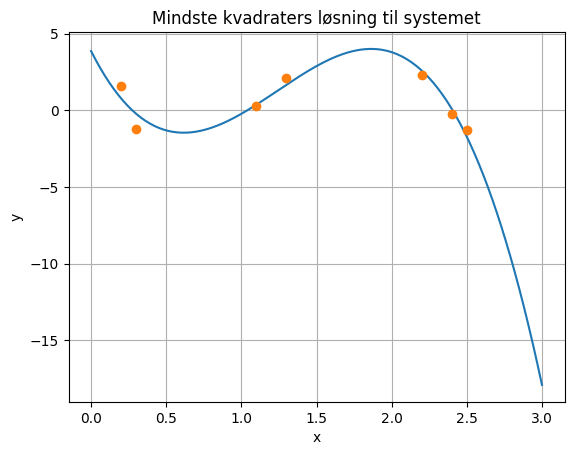

In [72]:
x = np.linspace(0, 3, 200)
y = w[0]*x**3 + w[1]*x**2 + w[2]*x + w[3]

fig, ax = plt.subplots()
ax.plot(x, y)
ax.plot(x_data, y_data, "o")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

## Opgave 7. (20 point) Betragt to beholder forbundet med rør, som i diagrammet nedenfor. {-}
Som udgangspunkt indeholder 𝑃 200 L (200 liter) vand og 150 g salt, hvor 𝑄
indeholder 100 L rent vand.
Der tilføjes 5 L/min ret vand via rør 𝑎. Der flyder 8 L/min blanding af salt
og vand igennem rør 𝑐 og 3 L/min igennem rør 𝑏. 5 L/min blanding forlader
systemet via rør 𝑑. Det følger at saltmængderne 𝑦0(𝑡) i 𝑃 og 𝑦1(𝑡) i 𝑄, målt i
gram, opfylder systemet

### (a) Bestem et tal 𝑐 ∈ℝså systemet (7.1) kan skrives på formen {-}


For at få matrixformen til at gå op med systemet i (7.1) skal $c$ få $cB$ til at være på formen:
$$
cB =
\begin{bmatrix}
-\frac{8}{200} & \frac{3}{100} \\
\frac{8}{200} & -\frac{8}{100}
\end{bmatrix}
$$
Hermed skal $c = \frac{1}{100}$. 

### (b) Udregn egenværdierne og tilhørende egenvektorer for 𝐵, uden brug af pythonfunktioner som np.linalg.eig.

Med koefficientmatricen $B$ kan det karakteristiske polynomium opstilles således:
\begin{align*}
\text{det}(B - \lambda I_{2})
 & = \text{det} \left(\begin{bmatrix}
-4 - \lambda & 3 \\
4 & - 8 - \lambda
\end{bmatrix}\right) \\
 & = (-4 - \lambda) (- 8 - \lambda) - 3 \cdot 4
\end{align*}

In [73]:
lam = sp.Symbol("lambda")

polynomium = sp.expand((-4 - lam)*(-8 - lam) - 3 * 4)
lambda0, lambda1 = sp.solve(polynomium, lam)
lambda0, lambda1 = float(lambda0), float(lambda1)
lambda0, lambda1

(-10.0, -2.0)

Egenvektorerne for $A$ ved at løse ligningssystemet $(A - \lambda I_{2}) v = 0$ for hver egenværdi.

In [74]:
B = np.array([[-4, 3],
              [4, -8]])

ligning0 = B - lambda0 * np.eye(2)
ligning0

array([[6., 3.],
       [4., 2.]])

In [75]:
ligning1 = B - lambda1 * np.eye(2)
ligning1

array([[-2.,  3.],
       [ 4., -6.]])

In [76]:
# Løsninger til de forskellige egenværdier kan være disse
v0 = np.array([1, -2], dtype=float)[:, np.newaxis]
v1 = np.array([3, 2], dtype=float)[:, np.newaxis]

print(f"Egenværdierne og deres tilhørende egenvektorer bliver da \n{lambda0}: \n{v0} \n\nog \n\n{lambda1}: \n{v1}")

Egenværdierne og deres tilhørende egenvektorer bliver da 
-10.0: 
[[ 1.]
 [-2.]] 

og 

-2.0: 
[[3.]
 [2.]]


### (c) Brug del (b) til at bestemme egenværdier og egenvektorer for 𝐴 =𝑐𝐵, og derefter den generelle løsning til systemet (7.1).

Når $A$ sættes til $cB$ skal det jvf. definition 21.1 stadig få følgende til at gå op:
$$
cB v = \lambda_{cB} v
$$
Da c blot er en skalar ganget på den ene side af lighedstegnet skal den ganges på den anden side på samme egenværdier fra før, for at det går op.
$$
cB v = c \lambda v
$$

De nye egenværdier bliver da $\lambda_{0} = -0.1, \, \lambda_{2} = -0.02$. Da egenvektorer kan have flere løsninger vil de tidligere egenvektorer kunne bruges igen. Dette skyldes igen at en skalar blot er ganget på, hvilket ikke ændrer deres vektorrum:
$$
v_{0} =
\begin{bmatrix}
1 \\
-2
\end{bmatrix}
, \, v_{1} =
\begin{bmatrix}
3 \\
2
\end{bmatrix}
$$

### (d) Bestem i python løsningen til (7.1), som opfylder startbetingelsen 𝑦0(0) = 150, 𝑦1(0) =0 og lav en plot af kvotienten 𝑦1(𝑡)/𝑦0(𝑡), som funktion af tid 𝑡. {-}


Der opstilles en ligning ud fra startværdien som forneden for at bestemme konstanterne $c_{0}$ og $c_{1}$.
$$
y(0) = c_{0} v_{0} + c_{1} v_{1} =
\begin{bmatrix}
90 \\
30
\end{bmatrix}
$$

In [77]:
lambda0 = -0.1
lambda1 = -0.02

b = np.array([150, 0], dtype=float)[:, np.newaxis]

lign = np.column_stack((v0, v1, b))
lign

array([[  1.,   3., 150.],
       [ -2.,   2.,   0.]])

In [78]:
lign[1] += 2*lign[0]
lign

array([[  1.,   3., 150.],
       [  0.,   8., 300.]])

In [79]:
lign[1] /= 8
lign

array([[  1. ,   3. , 150. ],
       [  0. ,   1. ,  37.5]])

In [80]:
lign[0] -= 3*lign[1]
lign

array([[ 1. ,  0. , 37.5],
       [ 0. ,  1. , 37.5]])

In [81]:
c0, c1 = lign[:, 2]
c0, c1

(37.5, 37.5)

Løsningerne til hhv. $y_{0}(t)$ og $y_{1}(t)$ bliver dermed
$$
y_{0}(t) = 37.5 \cdot 1 \cdot e^{-0.1 t} + 37.5 \cdot 3 \cdot e^{-0.02 t}
$$
$$
y_{1}(t) = -37.5 \cdot 2 \cdot e^{-0.1 t} + 37.5 \cdot 2 \cdot e^{-0.02 t}
$$

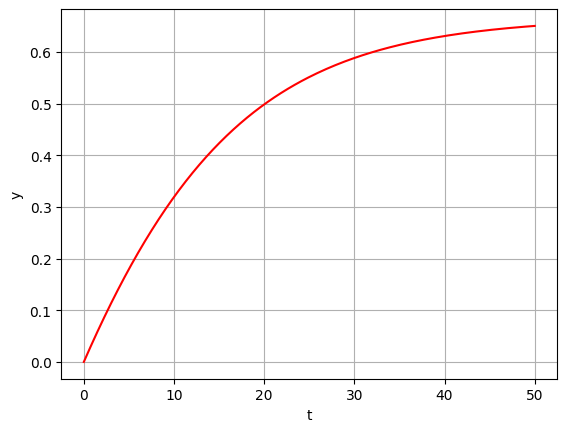

In [82]:
# Opstiller t-værdierne for en arbitrær definitionsmængde 
t = np.linspace(0, 50, 200)

# Opstiller løsningerne fra forrige opgave
y0 = c0 * v0[0] * np.exp(lambda0 * t) + c1 * v1[0] * np.exp(lambda1 * t)
y1 = c0 * v0[1] * np.exp(lambda0 * t) + c1 * v1[1] * np.exp(lambda1 * t)

# Plotter t op i mod hhv. y0 og y1
fig, ax = plt.subplots()
ax.plot(t, y1/y0, 'r')
plt.xlabel("t")
plt.ylabel("y")
ax.grid()